This notebook contains an exploratory analysis of the sales trend and seasonality across 54 stores availble in the [store sales](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data) dataset. The analysis is based on the average daily sales across the stores. By using the average daily sales, we will be able to get an overview of the sales trend and seasonality in each store.

**Key insights**:
* The dataset contains sales data from 2013-01-01 to 2017-08-15 for 54 stores each having 33 product families.
* The average number of sales over the period is approximately 358 items.
* The average daily sales appears be in an uptrend in period examined.
* There is a strong weekly seasonal pattern that shows an uptrend in the average sales during weekends.
* The monthly and annual seaonal patterns seems to be weak when compared to the weekly seasonal pattern.

This analysis provides some insights about the sales trend and seasonality in each store. However it is crucial to remember that using the average sales value across stores can mask individual store sales variations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from itertools import product

In [2]:
train_df = pd.read_csv("../data/raw/train.csv").sort_values(by="date")
train_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1194,1194,2013-01-01,42,CELEBRATION,0.0,0
1193,1193,2013-01-01,42,BREAD/BAKERY,0.0,0
1192,1192,2013-01-01,42,BOOKS,0.0,0
1191,1191,2013-01-01,42,BEVERAGES,0.0,0


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 160.3+ MB


In [4]:
train_df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [5]:
train_df.duplicated().sum()

np.int64(0)

In [6]:
train_df["store_nbr"].unique()

array([ 1, 42, 41, 43, 40,  4, 45, 44, 46, 36, 35, 37, 34, 39, 38, 54,  6,
       53, 52,  9,  8,  7, 48, 49, 47, 51, 50,  5, 33, 18, 17, 19, 16, 15,
       20,  2, 21, 11, 10, 12, 14, 13,  3, 30, 29, 28, 32, 31, 23, 24, 22,
       27, 26, 25])

In [7]:
train_df["store_nbr"].nunique()

54

In [8]:
train_df["family"].unique()

array(['AUTOMOTIVE', 'CELEBRATION', 'BREAD/BAKERY', 'BOOKS', 'BEVERAGES',
       'BEAUTY', 'BABY CARE', 'SEAFOOD', 'SCHOOL AND OFFICE SUPPLIES',
       'PRODUCE', 'PREPARED FOODS', 'POULTRY', 'PLAYERS AND ELECTRONICS',
       'PET SUPPLIES', 'PERSONAL CARE', 'MEATS', 'MAGAZINES',
       'LIQUOR,WINE,BEER', 'LINGERIE', 'LAWN AND GARDEN', 'LADIESWEAR',
       'HOME CARE', 'HOME APPLIANCES', 'CLEANING', 'DAIRY', 'DELI',
       'EGGS', 'HOME AND KITCHEN II', 'HOME AND KITCHEN I', 'HARDWARE',
       'GROCERY II', 'GROCERY I', 'FROZEN FOODS'], dtype=object)

In [9]:
train_df["family"].nunique()

33

In [10]:
train_df["date"] = pd.to_datetime(train_df["date"])

In [11]:
dates = train_df["date"].unique()

In [12]:
dates[[0, -1]]

<DatetimeArray>
['2013-01-01 00:00:00', '2017-08-15 00:00:00']
Length: 2, dtype: datetime64[ns]

In [13]:
# check for missing days
missing_dates = pd.date_range(dates[0], dates[-1]).difference(train_df["date"])
missing_dates

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

In [14]:
missing_data = list(product(missing_dates, train_df["store_nbr"].unique(), train_df["family"].unique()))

In [15]:
missing_rows = pd.DataFrame(missing_data, columns=["date", "store_nbr", "family"])
missing_rows.head()

,date,store_nbr,family
0,2013-12-25,1,AUTOMOTIVE
1,2013-12-25,1,CELEBRATION
2,2013-12-25,1,BREAD/BAKERY
3,2013-12-25,1,BOOKS
4,2013-12-25,1,BEVERAGES


In [16]:
train_df = pd.concat([train_df, missing_rows], ignore_index=True).sort_values(by="date").fillna(0)

In [17]:
(train_df["date"].unique() == pd.date_range(dates[0], dates[-1], freq="D")).all()

np.True_

In [18]:
train_df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [19]:
train_df.describe()

,id,date,store_nbr,sales,onpromotion
count,3.008016e+06,3008016,3.008016e+06,3.008016e+06,3.008016e+06
mean,1.496888e+06,2015-04-24 12:00:00.000000512,2.750000e+01,3.569279e+02,2.596603e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.448758e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.496880e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.248883e+06,2016-06-19 06:00:00,4.100000e+01,1.950000e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.683250e+05,NaN,1.558579e+01,1.100829e+03,1.220505e+01


In [20]:
avg_daily_sales = train_df.groupby("date")["sales"].mean()

## Trend Analysis

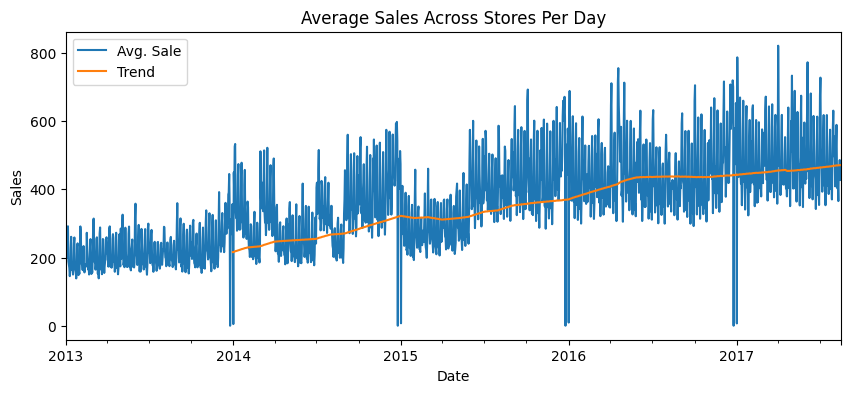

In [21]:
avg_daily_sales.plot(figsize=(10, 4), label="Avg. Sale")
avg_daily_sales.rolling(365).mean().plot(label="Trend")
plt.title("Average Sales Across Stores Per Day")
plt.ylabel("Sales")
plt.xlabel("Date")
plt.legend();

Based on the average sales across stores each day, we can assume that every store exhibits the same trend and seasonality from 2013 to 2017. The average sales across stores appear to be in an uptrend since 2013. There also appear to be seasonal periods where there is a decrease in sales at the beginning of each year and an increase in sales towards the end of the year.

In [22]:
sales_df = train_df[["date", "store_nbr", "sales"]].copy()
sales_df = sales_df.pivot_table(values="sales", index="date", columns="store_nbr")
sales_df = sales_df.add_prefix("store_")

In [23]:
sales_df.head()

store_nbr,store_1,store_2,store_3,store_4,store_5,store_6,store_7,store_8,store_9,store_10,...,store_45,store_46,store_47,store_48,store_49,store_50,store_51,store_52,store_53,store_54
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
2013-01-02,224.762061,311.112696,729.101455,309.093454,321.170273,409.711667,363.560667,444.222061,480.832848,164.548121,...,836.728817,822.724848,826.154879,596.969697,493.389242,502.307030,458.620939,0.0,0.0,150.705606
2013-01-03,177.977091,230.683030,562.749849,224.249848,235.483879,300.890697,281.150242,326.704333,316.112697,137.864545,...,526.605484,477.313788,555.763788,434.872243,300.275212,335.347425,338.486576,0.0,0.0,118.229394
2013-01-04,179.390273,228.072030,527.033273,209.153030,222.655818,268.763999,245.350698,337.110636,245.004818,102.455030,...,604.127122,517.365578,575.212393,462.933424,311.653515,368.104242,377.343212,0.0,0.0,98.998970
2013-01-05,191.478334,289.077758,687.905212,301.466152,248.260545,376.717850,260.927455,432.657546,395.670000,163.932879,...,821.340092,825.187819,818.068606,693.226485,409.273485,543.344364,455.946879,0.0,0.0,133.168152


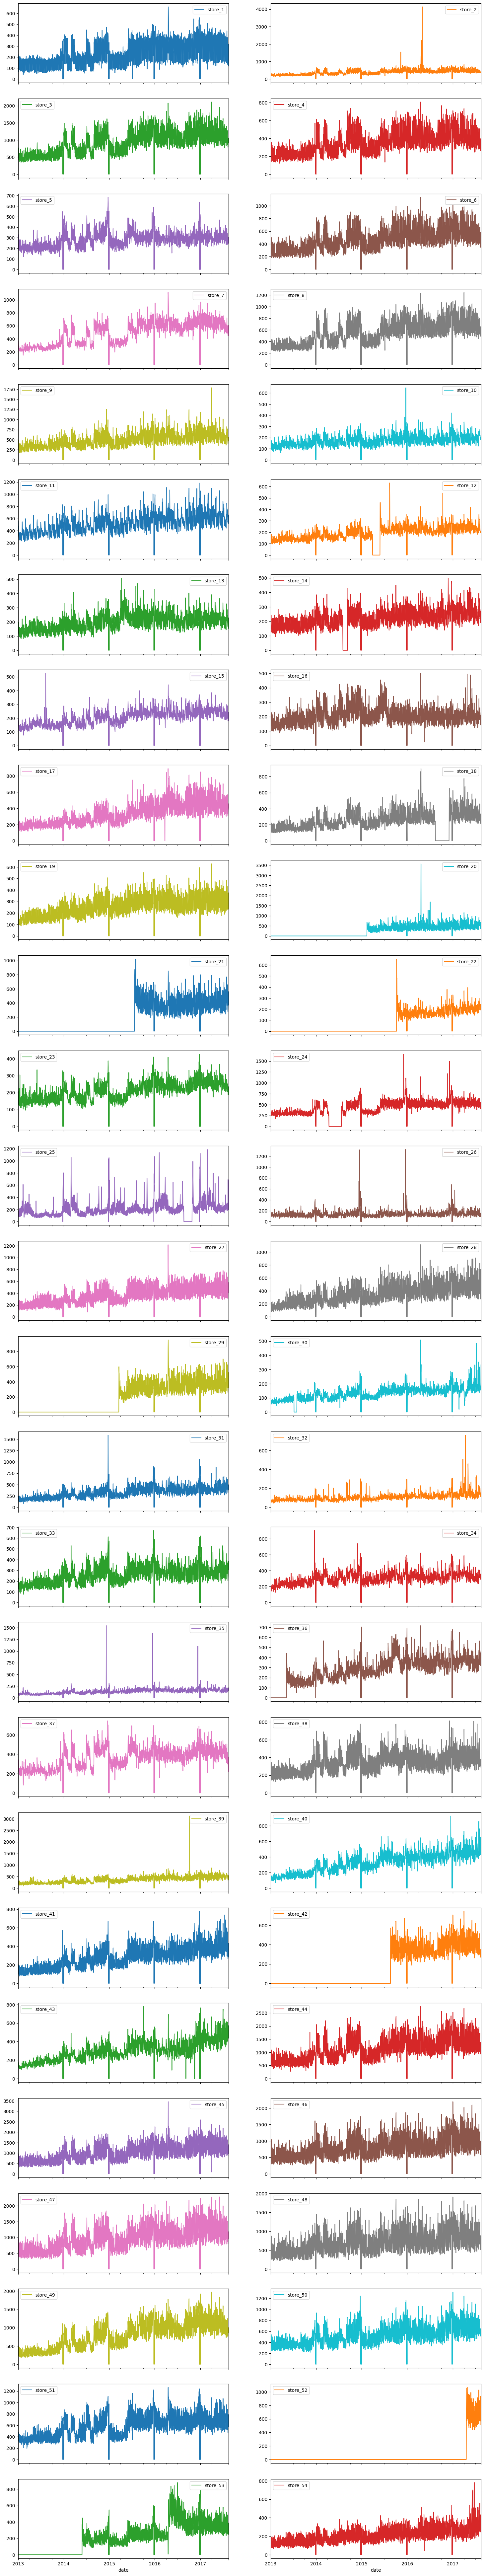

In [24]:
sales_df.plot(subplots=True, layout=(27, 2), figsize=(18, 100));

Most of the stores appear to have a similar trend as the average daily sales, however there are six stores that appear to have had zero sales for over a year, which is likely because the stores were not established for business at the same time as the other stores.

## Seasonality Analysis

In [25]:
avg_daily_sales_df = avg_daily_sales.to_frame("avg_sales")
avg_daily_sales_df["day_of_week"] = avg_daily_sales_df.index.day_of_week
avg_daily_sales_df["week"] = avg_daily_sales_df.index.isocalendar().week.astype(int)
avg_daily_sales_df["day_of_month"] = avg_daily_sales_df.index.day
avg_daily_sales_df["month"] = avg_daily_sales.index.month
avg_daily_sales_df["day_of_year"] = avg_daily_sales_df.index.dayofyear
avg_daily_sales_df["year"] = avg_daily_sales_df.index.year

In [26]:
# https://www.kaggle.com/code/ryanholbrook/seasonality/tutorial
def seasonal_plot(data, x, y, period):
    ax = plt.figure(figsize=(10, 4))
    palette = sns.color_palette("husl", n_colors=data[period].nunique())
    ax = sns.lineplot(
        data=avg_daily_sales_df,
        x=x,
        y=y,
        hue=period,
        palette=palette,
        errorbar=None
    )
    ax.set_title(f"Seasonal Plot [{period.title()}/Day]")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncols=3)
    return ax#, plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

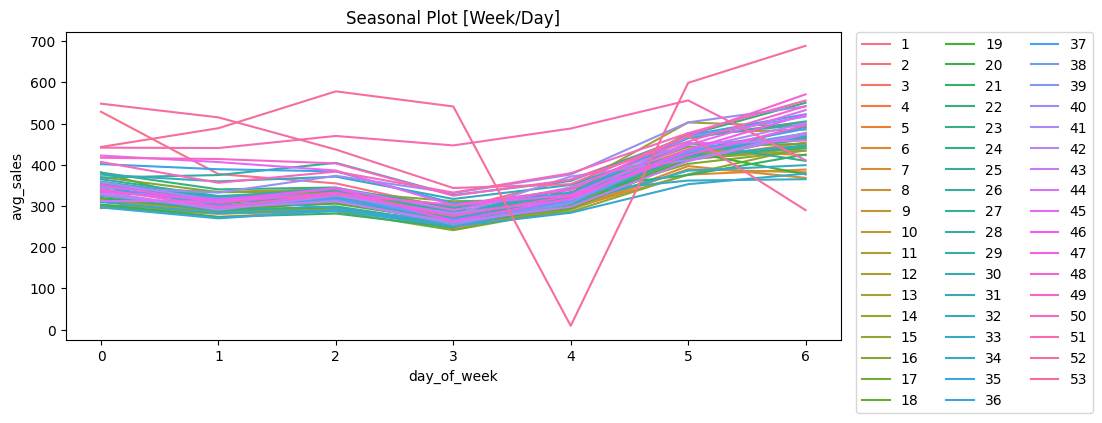

In [27]:
seasonal_plot(avg_daily_sales_df, "day_of_week","avg_sales", "week");

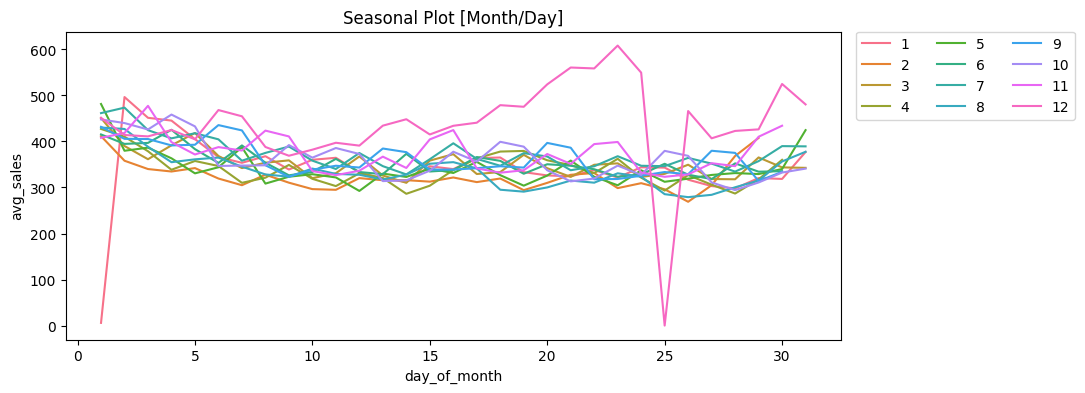

In [28]:
seasonal_plot(avg_daily_sales_df, "day_of_month","avg_sales", "month");

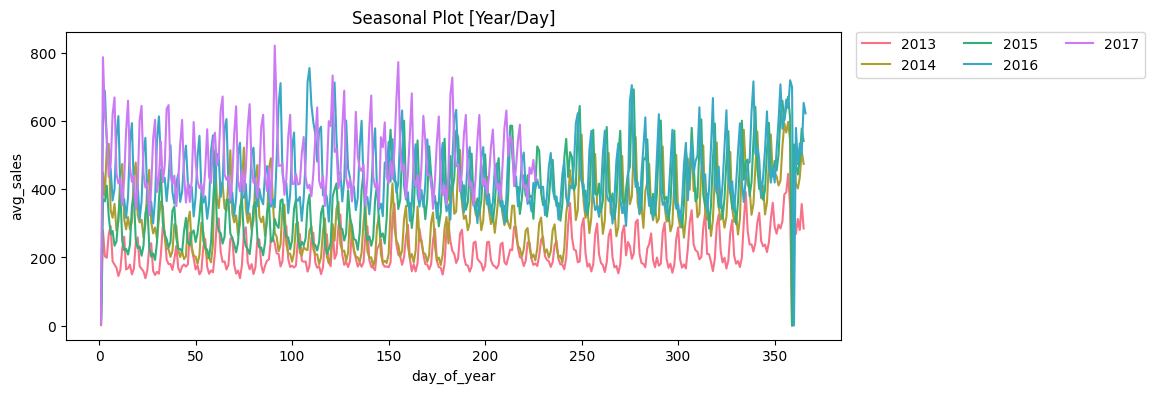

In [29]:
seasonal_plot(avg_daily_sales_df, "day_of_year","avg_sales", "year");

Based on the seasonal plots of the average daily sales, there appears to be a strong weekly season in the average sales across the stores per day. However, the monthly and annual seasons shows a weaker seasonal pattern.

In [30]:
# https://www.kaggle.com/code/ryanholbrook/seasonality/tutorial
def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

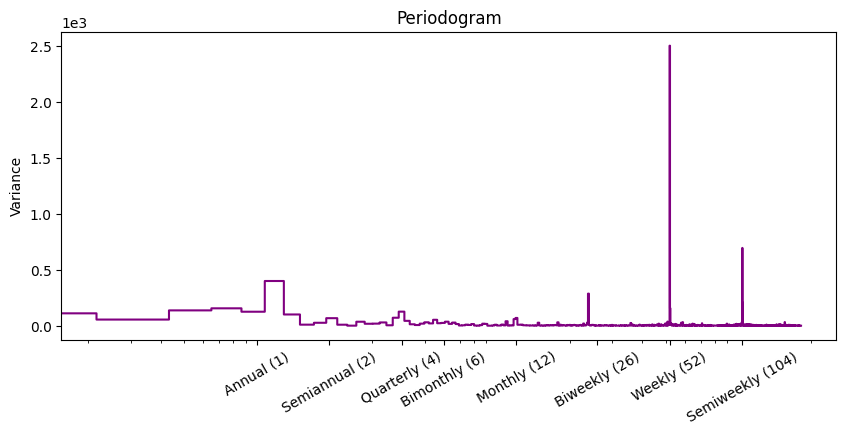

In [31]:
plot_periodogram(avg_daily_sales);

Additionally, based on the periodogram, the average sales across stores from 2013 to 2017 exhibit a strong weekly season and weak annual and monthly seasons.

## Autocorrelation Analysis

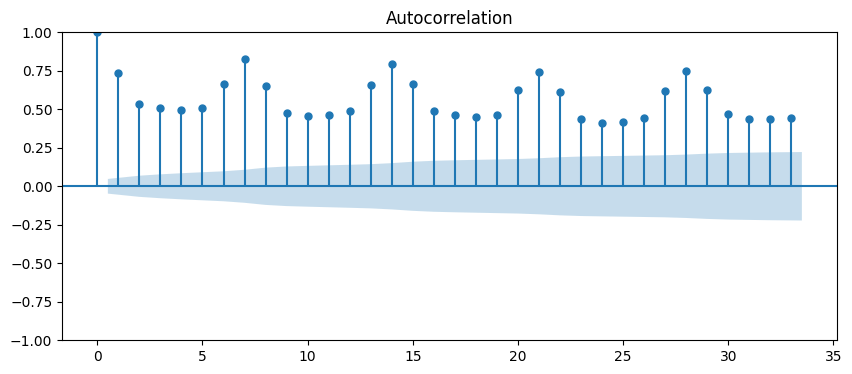

In [32]:
# autocorrection plot
_, ax = plt.subplots(figsize=(10, 4))
plot_acf(avg_daily_sales, ax=ax);

The peaks in the autocorrelation plot are seven days apart. This shows that the averaged daily sales across the stores exhibit a weekly seasonality.

In [33]:
lag_df = avg_daily_sales.to_frame()
col_name = lag_df.columns[0]
for lag in range(1, 16):
    lag_df[f"{col_name}_l{lag}"] = lag_df.iloc[:, 0].shift(lag)

In [34]:
import seaborn.objects as so

In [35]:
p = so.Plot(lag_df, y="sales").layout(size=(10, 6))

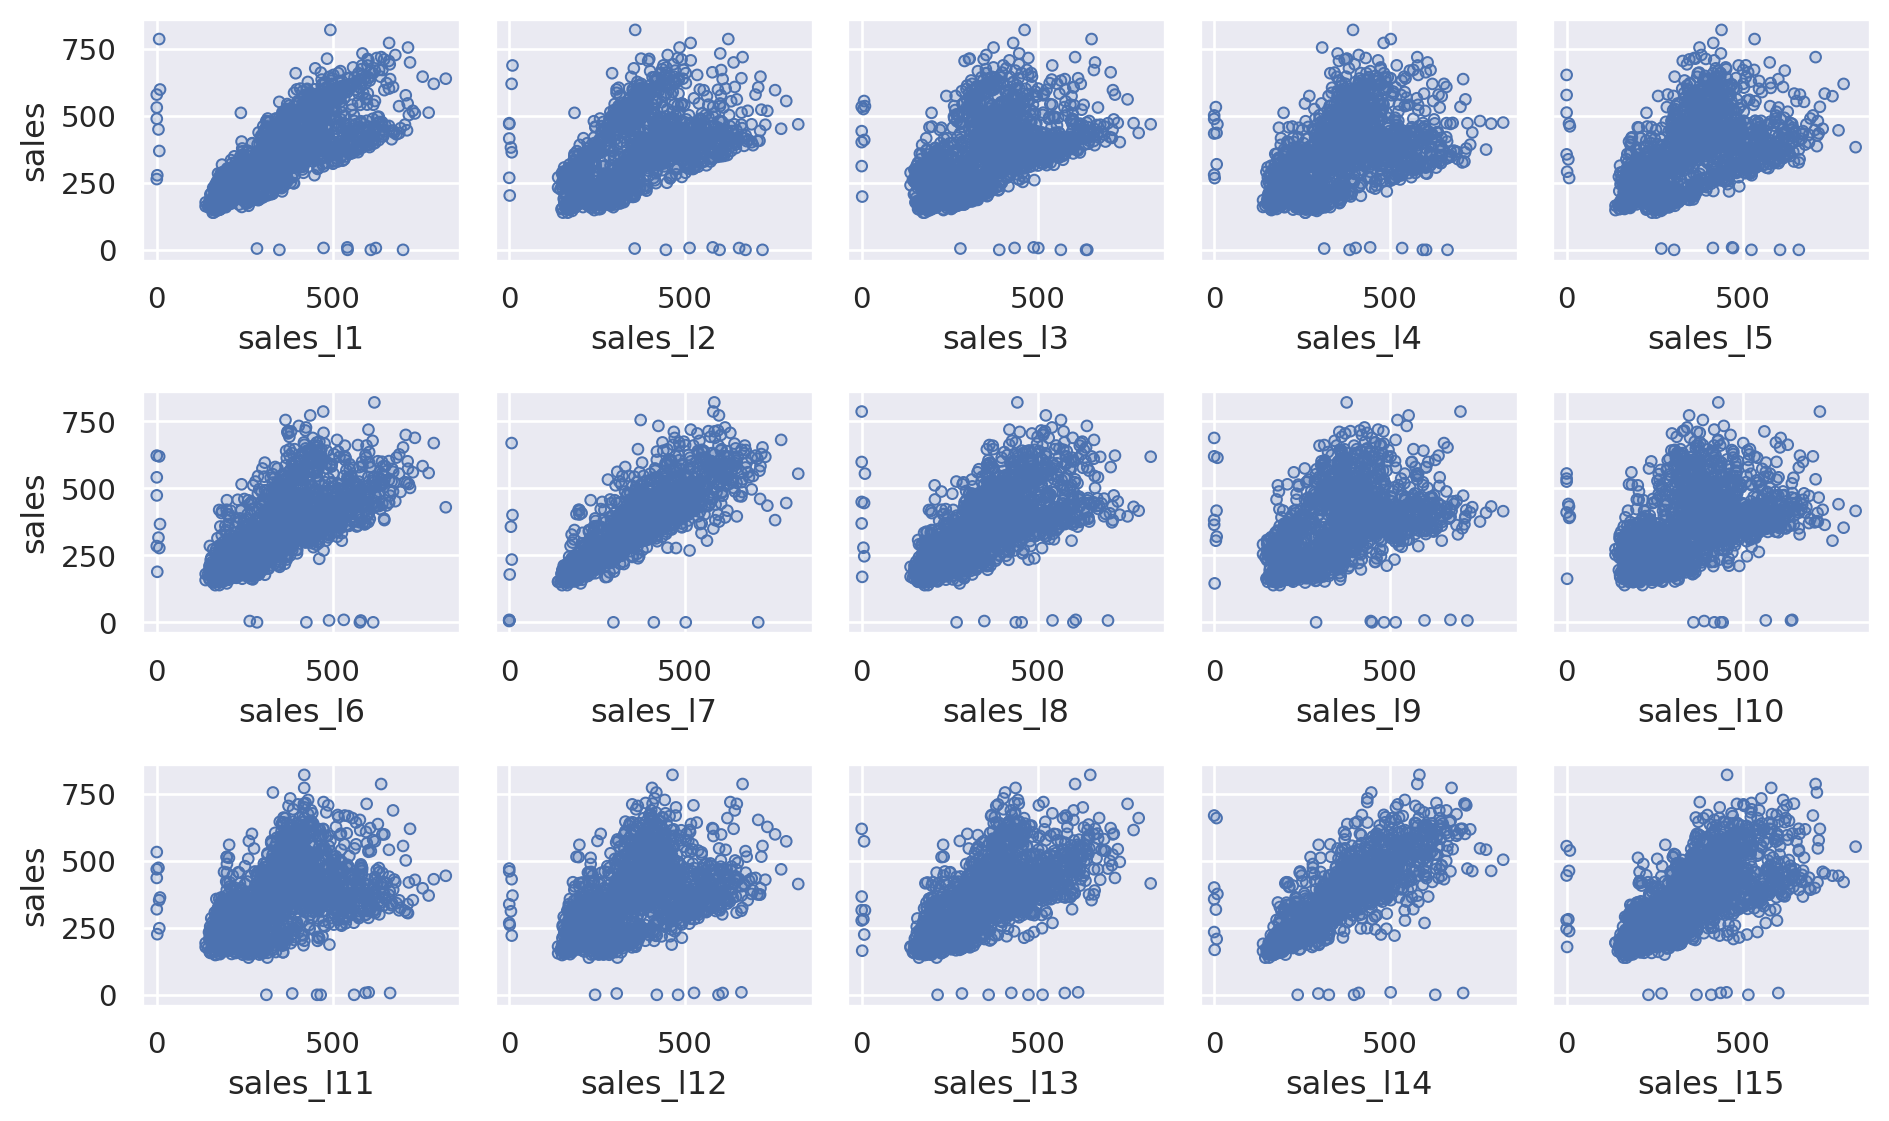

In [36]:
p.pair(x=lag_df.columns[1:], wrap=5).add(so.Dots())

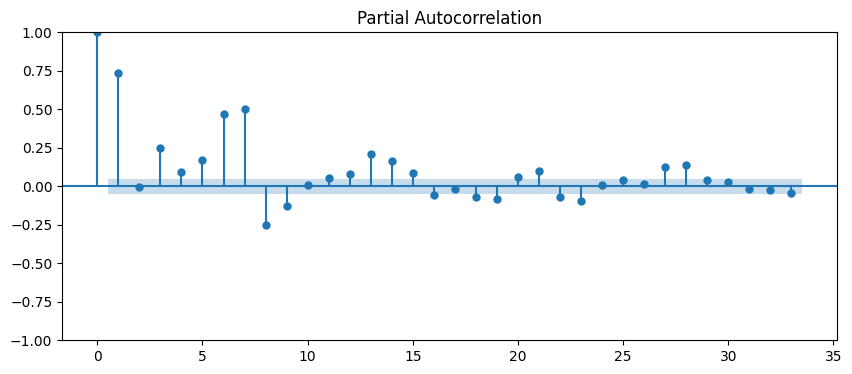

In [37]:
_, ax = plt.subplots(figsize=(10, 4))
plot_pacf(avg_daily_sales, ax=ax);

### References

https://www.kaggle.com/code/ryanholbrook/trend<br>
https://www.kaggle.com/code/ryanholbrook/seasonality/tutorial<br>
https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html<br>
https://en.wikipedia.org/wiki/Periodogram